In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import statsmodels as sm
import sklearn
import yfinance as yf

In [15]:
ticker = "^NSEI"

nifty = yf.download(
    ticker,
    start="2015-01-01",
    end=None,
    auto_adjust=True
)

[*********************100%***********************]  1 of 1 completed


In [17]:
nifty.head()

Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900
2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200
2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800
2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100
2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800


In [18]:
from statsmodels.tsa.stattools import adfuller, kpss


In [19]:
series = nifty["Close"].dropna()

In [20]:
adf_result = adfuller(series)

print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])
print("Lags Used     :", adf_result[2])
print("Observations  :", adf_result[3])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

ADF Statistic : -0.18359120657165479
p-value       : 0.9404494476987723
Lags Used     : 0
Observations  : 2839

Critical Values:
1%: -3.4327
5%: -2.8626
10%: -2.5673


In [21]:
kpss_result = kpss(series, regression="c")

print("KPSS Statistic :", kpss_result[0])
print("p-value        :", kpss_result[1])
print("Lags Used      :", kpss_result[2])

print("\nCritical Values:")
for key, value in kpss_result[3].items():
    print(f"{key}: {value}")

KPSS Statistic : 8.473791569969537
p-value        : 0.01
Lags Used      : 31

Critical Values:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


C:\Users\Sanatan Chhabra\AppData\Local\Temp\ipykernel_24624\4222395095.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression="c")


In [22]:
nifty["Close_Diff"] = nifty["Close"].diff()


In [24]:
diff_series = nifty["Close_Diff"].dropna()

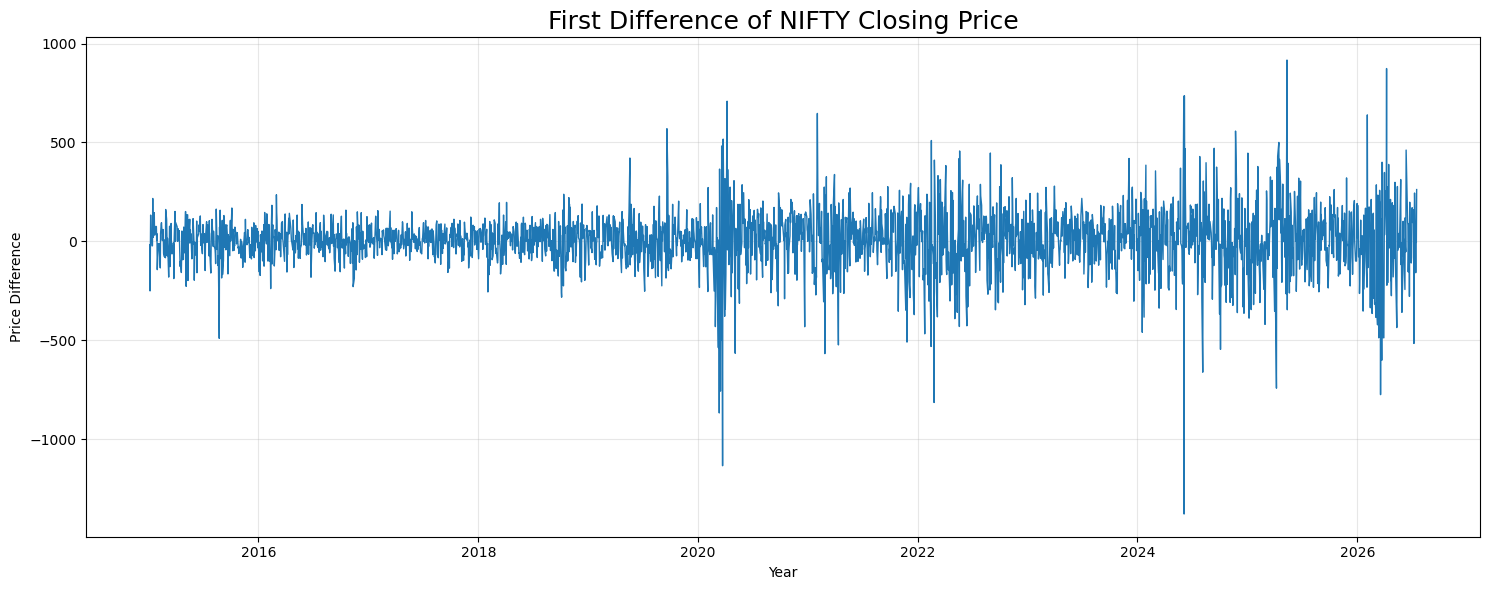

In [39]:
import os
from pathlib import Path

plt.figure(figsize=(15,6))

plt.plot(
    diff_series,
    linewidth=1
)

plt.title("First Difference of NIFTY Closing Price", fontsize=18)

plt.xlabel("Year")
plt.ylabel("Price Difference")

plt.grid(alpha=0.3)

plt.tight_layout()

FIGURES_DIR = Path(r"D:\NIFTY Time Series Forecasting\figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    "figures/first_difference.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
adf_diff = adfuller(diff_series)

print("ADF Statistic :", adf_diff[0])
print("p-value       :", adf_diff[1])

print("\nCritical Values:")

for key, value in adf_diff[4].items():
    print(f"{key}: {value:.4f}")

ADF Statistic : -25.79504024601608
p-value       : 0.0

Critical Values:
1%: -3.4327
5%: -2.8626
10%: -2.5673


In [33]:
kpss_diff = kpss(diff_series, regression="c")

print("KPSS Statistic :", kpss_diff[0])
print("p-value        :", kpss_diff[1])

print("\nCritical Values:")

for key, value in kpss_diff[3].items():
    print(f"{key}: {value}")

KPSS Statistic : 0.09874432271154958
p-value        : 0.1

Critical Values:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


C:\Users\Sanatan Chhabra\AppData\Local\Temp\ipykernel_24624\3579081610.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_diff = kpss(diff_series, regression="c")


In [34]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\NIFTY Time Series Forecasting\\Notebooks\\figures\\acf_plot.png'

<Figure size 1200x500 with 0 Axes>

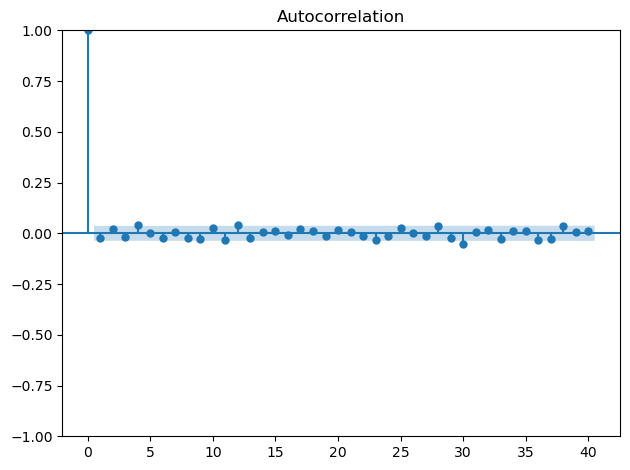

In [79]:
plt.figure(figsize=(12,5))

plot_acf(
    diff_series,
    lags=40
)

plt.tight_layout()
FIGURES_DIR = Path(r"D:\NIFTY Time Series Forecasting\figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(
    "figures/acf_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\NIFTY Time Series Forecasting\\Notebooks\\figures\\pacf_plot.png'

<Figure size 1200x500 with 0 Axes>

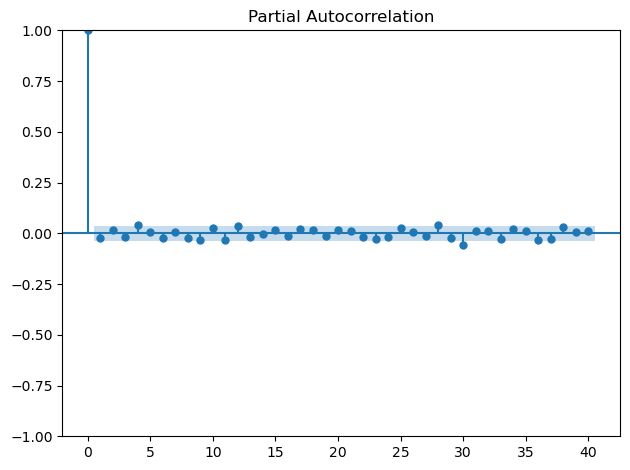

In [78]:
plt.figure(figsize=(12,5))

plot_pacf(
    diff_series,
    lags=40,
    method="ywm"
)

plt.tight_layout()

plt.savefig(
    "figures/pacf_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
from statsmodels.tsa.arima.model import ARIMA

In [45]:
orders = [
    (0,1,0),
    (1,1,0),
    (0,1,1),
    (1,1,1),
    (2,1,1),
    (1,1,2)
]

results = []

for order in orders:
    model = ARIMA(df["Close"], order=order)
    fitted = model.fit()

    results.append({
        "Model": f"ARIMA{order}",
        "AIC": fitted.aic,
        "BIC": fitted.bic
    })

d:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Anaconda\Lib\site-packages\statsmodel

In [46]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df = results_df.sort_values("AIC")

results_df

,Model,AIC,BIC
3,"ARIMA(1, 1, 1)",36392.499768,36410.353390
0,"ARIMA(0, 1, 0)",36393.780135,36399.731342
4,"ARIMA(2, 1, 1)",36394.339908,36418.144737
5,"ARIMA(1, 1, 2)",36394.343091,36418.147920
1,"ARIMA(1, 1, 0)",36394.570901,36406.473315
2,"ARIMA(0, 1, 1)",36394.615177,36406.517591


In [47]:
best_model = ARIMA(df["Close"], order=(1,1,1))
best_fit = best_model.fit()

print(best_fit.summary())

d:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  ^NSEI   No. Observations:                 2840
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -18193.250
Date:                Sun, 19 Jul 2026   AIC                          36392.500
Time:                        22:40:40   BIC                          36410.353
Sample:                             0   HQIC                         36398.940
                               - 2840                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9594      0.029    -33.429      0.000      -1.016      -0.903
ma.L1          0.9472      0.032     29.584      0.000       0.884       1.010
sigma2      2.156e+04    261.639     82.417      0.0

In [48]:
train_size = int(len(df) * 0.8)

train = df["Close"][:train_size]
test = df["Close"][train_size:]

print("Training observations:", len(train))
print("Testing observations :", len(test))

Training observations: 2272
Testing observations : 568


In [49]:
model = ARIMA(train, order=(1,1,1))

model_fit = model.fit()

print(model_fit.summary())

d:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  ^NSEI   No. Observations:                 2272
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -14220.594
Date:                Sun, 19 Jul 2026   AIC                          28447.188
Time:                        22:46:30   BIC                          28464.372
Sample:                             0   HQIC                         28453.457
                               - 2272                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1293      0.967     -0.134      0.894      -2.024       1.766
ma.L1          0.1408      0.964      0.146      0.884      -1.748       2.030
sigma2      1.608e+04    236.249     68.058      0.0

In [50]:
forecast = model_fit.forecast(steps=len(test))

d:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [51]:
forecast.head()

2272    22125.172951
2273    22124.976055
2274    22125.001517
2275    22124.998224
2276    22124.998650
Name: predicted_mean, dtype: float64

In [61]:
forecast_result = model_fit.get_forecast(steps=len(test))

forecast = forecast_result.predicted_mean

forecast.index = test.index

conf_int = forecast_result.conf_int()
conf_int.index = test.index

d:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


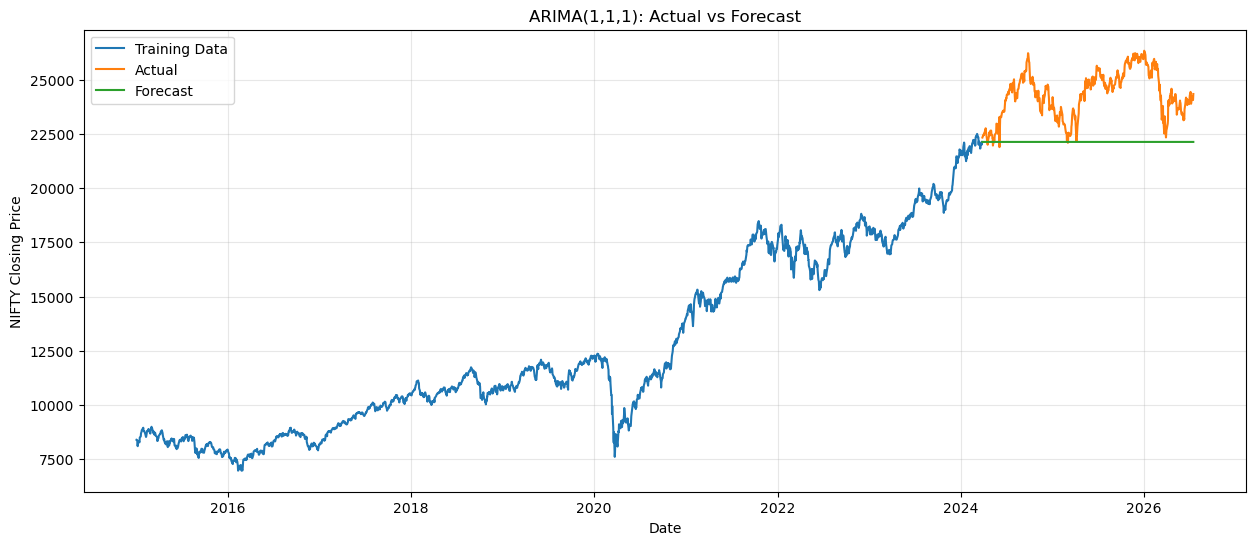

In [81]:
plt.figure(figsize=(15,6))

plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual")
plt.plot(forecast.index, forecast, label="Forecast")

plt.title("ARIMA(1,1,1): Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("NIFTY Closing Price")
plt.legend()
plt.grid(alpha=0.3)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    FIGURES_DIR / "arima_forecast_2.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [63]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

In [65]:
mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(mean_squared_error(test, forecast))

mape = np.mean(np.abs((test - forecast) / test)) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 2212.270133784927
RMSE: 2459.1910564259465
MAPE: nan


In [67]:
print("NaNs in test:", test.isna().sum())
print("NaNs in forecast:", forecast.isna().sum())

print("Length of test:", len(test))
print("Length of forecast:", len(forecast))

NaNs in test: Ticker
^NSEI    0
dtype: int64
NaNs in forecast: 0
Length of test: 568
Length of forecast: 568


In [68]:
print(test.index.equals(forecast.index))

True


In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

actual = test.to_numpy()
pred = forecast.to_numpy()

mae = mean_absolute_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))
mape = np.mean(np.abs((actual - pred) / actual)) * 100

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE : 2212.27
RMSE: 2459.19
MAPE: 8.91%


In [70]:
from statsmodels.tsa.arima.model import ARIMA

history = list(train)

predictions = []

In [75]:
history = train.iloc[:, 0].tolist()
predictions = []


    for t in range(len(test)):
        model = ARIMA(history, order=(1,1,1))
        model_fit = model.fit()
        yhat = model_fit.forecast()[0]
        predictions.append(yhat)
        history.append(test.iloc[t, 0])


d:\Anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
d:\Anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [76]:
predictions = pd.Series(predictions, index=test.index)

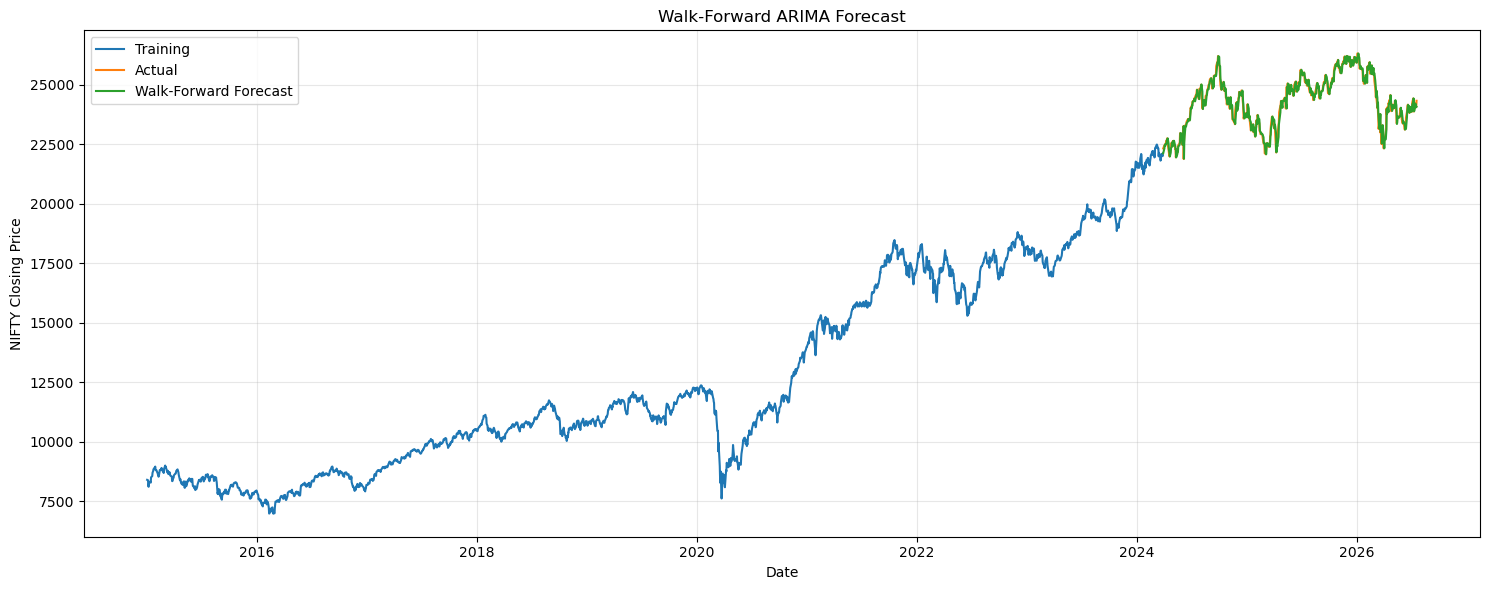

In [83]:
plt.figure(figsize=(15,6))

plt.plot(train.index, train, label="Training")

plt.plot(test.index, test, label="Actual")

plt.plot(predictions.index,
         predictions,
         label="Walk-Forward Forecast")

plt.title("Walk-Forward ARIMA Forecast")

plt.xlabel("Date")

plt.ylabel("NIFTY Closing Price")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    FIGURES_DIR / "walk_forward_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
mape = np.mean(np.abs((test - predictions) / test)) * 100

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE : 149.14
RMSE: 209.07
MAPE: nan%


In [85]:
print(test.isna().sum())
print(predictions.isna().sum())

print(test.index.equals(predictions.index))

Ticker
^NSEI    0
dtype: int64
0
True


In [86]:
print((test == 0).sum())

Ticker
^NSEI    0
dtype: int64


In [87]:
actual = test.to_numpy()
pred = predictions.to_numpy()

mape = np.mean(np.abs((actual - pred) / actual)) * 100

print(f"MAPE: {mape:.2f}%")

MAPE: 5.12%


In [88]:
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE : 149.14
RMSE: 209.07
MAPE: 5.12%
